# Tema 4: Integrales y derivadas

## Integrales

#### Trapecio

In [15]:
import numpy as np

a = 0
b = 1

N = 200
w = np.ones(N)
w[0] = w[-1] = 1/2
x = np.linspace(a,b,N)
h = x[1]-x[0]

f = lambda x: x**2

I = h*np.sum(w*f(x))
print(I)

0.3333375419812631


#### Trapecio adaptado

In [41]:
import numpy as np

def trap_adapt(f, a, b, tol):
    N = 1 # Se puede subir porque con toda seguridad nos hará falta más que una sola caja, así que nos ahorramos iteraciones
    err = 1.0
    h = b-a
    I1 = h/2*(f(a)+f(b))
    while err > tol:
        N*= 2
        h /= 2
        I2 = I1/2
        I2 += h*np.sum([f(a+k*h) for k in range(1,N,2)])
        err = 1/3*np.abs(I2-I1)
        I1 = I2
    return I1

f = lambda x: x**2

print(trap_adapt(f, 0, 1, 10**(-6)))

0.33333396911621094


**Errror del trapecio:** $\epsilon_{trap} = \frac{h^2}{12}(f'(a)-f'(b))$

#### Simpson

In [19]:
import numpy as np

a = 0
b = 1

N = 3 # Mínimo. Esto es a, punto central, b. Es el equivalente a una caja de Simpson

w = np.ones(N)
x = np.linspace(a,b,N)

h = x[1]-x[0]

w[0] = w[-1] = 1
w[1:N:2] = 4
w[2:N-1:2] = 2

w/=3

f = lambda x: x**2

I = h*np.sum(w*f(x))

print(I)

0.3333333333333333


**Error de simpson:** $\epsilon_{simpson} = \frac{h^4}{90}(f'''(a)-f'''(b))$

#### Simpson adaptado

In [1]:
import numpy as np

def simpson_adapt(f, a, b, tol):
    N=2
    h = (b-a)/N
    
    S0 = 1/3*(f(a)+f(b))
    T0 = 2/3*f(a+h)
    I0 = h*(S0+2*T0)
    
    n = 1
    err = 1.0
    while err > tol:
        n+=1
        N*=2
        h/=2
        
        S1 = S0+T0
        T1 = 2/3*np.sum([f(a+k*h) for k in range(1,N,2)])
        I1 = h*(S1+2*T1)
        
        err = 1/15*np.abs(I1-I0)
        
        S0=S1
        T0=T1
        I0=I1
    return I0, n

f = lambda x: x**5

I, it = simpson_adapt(f, 0,1, 10**(-6))
print(I, it)

0.16666698455810547 5


#### Romberg

In [2]:
import numpy as np

def romb(f, a, b, tol):
    N = 1
    h=b-a
    
    R11 = h/2*(f(a)+f(b))
    R1 = np.array([R11], float)
    
    err = 1.0
    n = 1
    
    while err > tol:
        N*=2
        h/=2
        n+=1
        
        R21 = R11/2 + h*np.sum([f(a+k*h) for k in range(1,N,2)])
        
        R2 = np.empty(n, float)
        R2[0]=R21
        
        for i in range(1,n):
            error = (R2[i-1]-R1[i-1])/(4**i-1)
            R2[i]=R2[i-1]+error
        err = np.abs(error)
        R11=R21
        R1=R2
    return (R1[-1], err, n)

f = lambda x: x**5

I, err, it = romb(f, 0, 1, 10**(-6))
print(I, it)

0.16666666666666666 4


#### Gauss

In [13]:
import numpy as np
from gaussxw import gaussxw

N=3
x, w = gaussxw(N)

a=0
b=1
x = 1/2*((b-a)*x+(b+a))
w = 1/2*(b-a)*w

f = lambda x: x**5

I = np.sum(w*f(x))
print(I)

0.16666666666666696


### Cambios de variable

#### Rango $[0,\infty]$ ó $[-\infty,0] \longrightarrow [0,1]$

$$z=\frac{x}{x+1}\quad\Rightarrow\quad x=\frac{z}{1-z},\quad dx=\frac{\text{d}z}{(1-z)^2}$$

$$\int\limits_0^\infty\,f(x)\,\text{d}x = \int\limits_{0}^1\frac{1}{(1-z)^2}\,f\left(\frac{z}{1-z}\right)\,\text{d}z,$$

En general: $$z=\frac{x^\gamma}{x^\gamma+c}\quad \forall\,c,\gamma >0$$



$$x=\frac{1}{c^\gamma}\left(\frac{z}{1-z}\right)^{1/\gamma}$$

$$dx = \frac{1}{\gamma c^\gamma}\frac{1}{z^2}\left(\frac{z}{1-z}\right)^{1/\gamma+1}dz$$

#### Rango $[a,\infty]$ ó $[-\infty,b]\longrightarrow [0,1]$

$$z=\frac{x-a}{x-a+1}\quad\Rightarrow\quad x=\frac{z}{1-z}+a,\quad dx=\frac{\text{d}z}{(1-z)^2}$$

#### Rango $[-\infty,\infty]\longrightarrow [-\pi/2,+\pi/2]$ ó $[-1,1]$  ó separación en 2 integrales

$$[-1,1]  \quad\quad x=\frac{z}{1-z^2},\quad dx=\frac{1+z^2}{(1-z^2)^2}\text{d}z,$$

$$[-\pi/2,+\pi/2] \quad\quad x=\tan\,z,\quad dx=\frac{\text{d}z}{\cos^2z},$$

### Integrales de varias variables

#### Recinto rectangular

In [14]:
from gaussxw import gaussxw
import numpy as np

N=50

x, w = gaussxw(N)

a = 0
b = 2
roots_x, w_x = 1/2*((b-a)*x + (b+a)), 1/2*(b-a)*w

a = 0
b = 1
roots_y, w_y = 1/2*((b-a)*x + (b+a)), 1/2*(b-a)*w

def f(x, y):
    return x**2*y

X, Y = np.meshgrid(roots_x, roots_y)
WX, WY = np.meshgrid(w_x, w_y)

I=WY*WX*f(X, Y)
I=np.sum(I)

# I=0
# for i in range(N):
#     for j in range(N):
#         I+=w_y[i]*w_x[j]*f(roots_x[j], roots_y[i])

print(I)
print(4/3)

1.3333333333333344
1.3333333333333333


#### Límites de integración dependientes

Ejemplo: $$I=\int_0^1\int_0^xx^2ydydx = 0.1$$

In [24]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
w = np.ones(N)
w[0] = w[-1] = 1/2

x = np.linspace(0,1,N)
hx = x[1]-x[0]

f = lambda x, y: x**2*y

def Fx(x0):
    y = np.linspace(0,x0,N)
    hy = y[1]-y[0]
    I = hy*np.sum(w*f(x0,y))
    return I

Fx = np.vectorize(Fx)

I = hx*np.sum(w*Fx(x))
print(I)

0.10000420863730215


## Derivadas

### Ordinarias

#### Adelantadas

In [28]:
import numpy as np

def der_adelant(f, x0):
    h = 10**(-8)
    return (f(x0+h)-f(x0))/h

#### Retrasadas

In [32]:
import numpy as np

def der_ret(f, x0):
    h = 10**(-8)
    return (f(x0)-f(x0-h))/h

#### Centradas

In [35]:
import numpy as np

def der_cent(f, x0):
    h = 10**(-5)
    return (f(x0+h/2)-f(x0-h/2))/h

### Parciales 

In [44]:
import numpy as np

# Hay que definir en qué dirección queremos evaluar la parcial. Hago el ejemplo de la parcial en la dirección
# x para una función de 2 variables

def parcial_cent(f, x0, y0):
    h = 10**(-5)
    return (f(x0+h/2,y0)-f(x0-h/2,y0))/h

f = lambda x, y: x**2 + y**2
parcial_cent(f, 1,1)

2.0000000000131024

### Gradiente

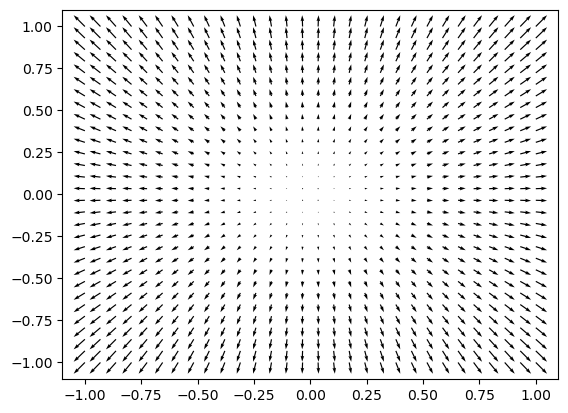

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Hacemos derivada adelant. / ret. en los extremos y en el resto de puntos hacemos der. cent

# Código para gradiente de un campo escalar. En los extremos hacemos derivadas adelantadas y retrasadas,
# y en el resto las hacemos centradas
        
# MAL, TIENES QUE DECIRME EL PASO TEMPORAL
def der_x(V):
    der_x = np.empty_like(V)

    der_x[:,0] = V[:,1]-V[:,0]
    der_x[:,-1] = V[:,-1]-V[:,-2]
    for i in range(1,len(V)-1):
        der_x[:,i] = (V[:,i+1]-V[:,i-1])/2
    return der_x

def grad_pts(V): # Funciona exactamente igual que numpy.gradient
    gradx = der_x(V)
    grady = der_x(V.T).T
    
    return (gradx, grady)

# Cuando tenemos V con expresión analítica --> tomamos puntos
x = np.linspace(-1, 1, 30)
y = np.linspace(-1, 1, 30)
    
X, Y = np.meshgrid(x, y)

def grad_f(V, X, Y):
    return grad_pts(V(X, Y))

V = lambda x, y: x**2+y**2

gradx, grady = grad_f(V, X, Y)

plt.quiver(X, Y, gradx, grady)
plt.show()

# Tema 5: Ecuaciones lineales y autovalores

## Sistemas de ecuaciones lineales

### Elim. gaussiana con pivote

In [3]:
import numpy as np

def make_triang_sup(AB):
    N = len(AB)
    for i in range(N):
        sub_col = AB[i:,i]
        pivot = np.max(sub_col)
        ind = np.where(sub_col==pivot)[0][0]+i
        
        AB[i,:], AB[ind, :] = AB[ind, :].copy(), AB[i, :].copy()
        
        # Ahora implementamos método de eliminación Gaussiana normal sabiendo que ya no hay riesgo de tener pivote nulo
        AB[i:, :] /= pivot # No hace falta dividir toda la fila porque hay i 0s en la i-ésima fila
        for k in range(i+1, N):
            mult = AB[k,i]
            AB[k, i:] -= mult*AB[i,i:] # No hace falta restar la fila entera porque estamos haciendo muchas cuentas de 0-0
    return AB


def sust_atras(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N-1, -1, -1):
        x[i] = B[i]
        for n in range(i+1, N):
            x[i] -= A[i, n]*x[n]
        x[i] /= d[i]
    return x
    
def sust_adelant(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N):
        x[i] = B[i]
        for n in range(i):
            x[i]-=A[i,n]*x[n]
        x[i] /= d[i]
    return x

### LUP

In [4]:
import numpy as np

def LUP(A): # Programa que factoriza A en matrices triangular inf y sup
    U = A.copy()
    L = np.zeros_like(U)
    
    
    N = len(A)
    P = np.eye(N)
    
    for i in range(N):
        L[i:,i] = U[i:,i]
        
        subcol = U[i:,i]
        pivot = np.max(subcol)
        ind = np.where(subcol==pivot)[0][0]+i
        
        U[i,:], U[ind, :] = U[ind, :].copy(), U[i, :].copy()
        L[i,:], L[ind, :] = L[ind, :].copy(), L[i, :].copy()
        P[i,:], P[ind, :] = P[ind, :].copy(), P[i, :].copy()
        
        U[i,:] /= pivot

        for k in range(i+1, N):
            mult = U[k,i]
            U[k,:] -= mult*U[i,:]
    return L, U, P

def solveLU(L, U, PV):
    # Se trata ahora de resolver dos sistemas de ecuaciones
    # 1. Ly == PV (sust hacia delante)
    # 2. Ux = y (sust hacia atrás)
    
    y = sust_adelant(L, PV)
    x = sust_atras(U, y)
    return x

A=np.array([[2,1,4,1],[3,4,-1,-1],[1,-4,1,5],[2,-2,1,3]],float)
B=np.array([-4,3,9,7],float)

L, U, P = LUP(A)

print(solveLU(L, U, np.dot(P, B)))

[ 2. -1. -2.  1.]


## Inversa de una matriz

Se trata de encontrar $A^{-1}$ tal que $AA^{-1}=I$. Podemos plantearlo como un sistema de ecuaciones, donde cada columna de $A^{-1}$ es el vector $X$ que deseamos calcular, y donde cada columna de la matriz identidad es la matriz de solución $B$. Como hay que operar $N$ veces, lo óptimo es proceder por LU(P) ya que así solo factorizamos $A$ una vez y solo queda hacer sustitución adelantada y atrasada, que es rápido

In [9]:
import numpy as np

def inv(A):
    N = len(A)
    I = np.eye(N)
    A_inv = np.empty_like(A)
    
    L, U, P = LUP(A)
    
    B=np.dot(P, I)
    
    for i in range(N):
        A_inv[:,i] = solveLU(L, U, B[:,i])
    return A_inv

## Matrices tridiagonales

In [10]:
# Para optimizar el algoritmo de la eliminación Gaussiana, tengo que saltarme las filas en las que haya pivote 0

import numpy as np

def tridiagonal(A, B):
    N = len(B)
    for i in range(N-1): # Solo tengo que ir hasta la penúltima fila porque en la última solo voy a dividir
        # Asumo que el primer elemento es 1 aunque no lo sea
        
        # Divido la fila por el pivote
        div = A[i,i]
        A[i,i+1] /= div
        B[i] /= div
        
        # Asumo que el término de abajo es 0 porque total ya lo voy a eliminar, así me ahorro 1 op
        # Resto la fila a la de abajo
        mult = A[i+1,i]
        A[i+1,i+1] -= A[i,i+1]*mult
        B[i+1] -= B[i]*mult
        
    # Última fila
    B[N-1] /= A[N-1,N-1]
    
    # Doy la solución
    x = np.empty(N, float)
    x[N-1] = B[N-1]
    for i in range(N-2, -1, -1): # Fíjate en que los elementos de la diagonal de A nunca aparecen --> por eso asumo que son 1
        x[i] = B[i]- A[i,i+1]*x[i+1]

    return x

N = 4
A = np.zeros((N,N), float)

k = 5
m = 1
w = 2
a = 2*k-m*w**2
C = 1

for i in range(1, N-1):
    A[i,i] = a
    A[i,i-1] = -k
    A[i,i+1] = -k


A[0,0] = a-k
A[0,1]=-k
A[-1,-1] = a-k
A[-1,-2] = -k

B = np.zeros(N)
B[0] = C

x = tridiagonal(A, B)
print(x)

[-0.41369048 -0.2827381   0.07440476  0.37202381]


## Autovalores y autovectores

### Factorización QR

In [18]:
import numpy as np

def QR_fact(A):
    N = len(A)
    Q = np.zeros((N,N), float)
    R = np.zeros((N,N), float)
    U = np.zeros((N,N), float)
    
    for m in range(N):
        U[:,m] = A[:,m]
        for i in range(m): # En la primera iteración de i no entra
            R[i,m] = np.dot(Q[:,i], A[:,m])
            U[:,m] -= R[i,m]*Q[:,i]
        R[m,m] = np.linalg.norm(U[:,m])
        Q[:,m] = U[:,m]/R[m,m]
    
    return Q,R

A = np.array([[1, 4, 8, 4], [4, 2, 3, 7], [8, 3, 6, 9], [4, 7, 9, 2]], float)

Q, R = QR_fact(A)

print(np.matmul(Q, R))

[[1. 4. 8. 4.]
 [4. 2. 3. 7.]
 [8. 3. 6. 9.]
 [4. 7. 9. 2.]]


### Diagonalización con QR sucesivos

In [24]:
import numpy as np

def eigvals(A, tol): # Solo para autovalores
    err = 1.0
    mask = ~np.eye(A.shape[0],dtype=bool)
    while err > tol:
        Q, R = QR_fact(A)
        A1 = np.dot(R, Q)
        
        err = np.max(np.abs(A1[mask]))
        A = A1
    return np.diag(A)

def eig(A, tol): # Autovalores y autovectores
    err = 1.0
    mask = ~np.eye(A.shape[0],dtype=bool)
    V = np.eye(len(A))
    while err > tol:
        Q, R = QR_fact(A)
        A1 = np.dot(R, Q)
        V = np.dot(V, Q)
        
        err = np.max(np.abs(A1[mask]))
        A = A1
    return np.diag(A), V
    